# TSMixer as a Global ETF Sequence Model

TSMixer asks the same question as [`09_dl_lstm`](09_dl_lstm.ipynb) with a different inductive
bias. One set of parameters is fitted across the whole panel, and each training example carries
one fund's own history and covariates, so the mixing layers learn temporal and within-series
feature interactions that every fund shares. They do not mix one fund's observations into
another fund's forecast: what is shared is the function, not the data.

It also runs on a different backend from the recurrent model, which is why it is a separate
notebook rather than another configuration in the same sweep.

**Learning objectives**
- Declare a sequence population and resolve it against the data before any fitting happens
- Tune the epoch checkpoint on the validation folds without reading the holdout, under a
  full-coverage guard that excludes checkpoints whose predictions collapsed on some folds
- Place a globally shared sequence model against the linear and gradient-boosting leaders on the
  same cross-section

**Book reference**: Chapter 13, Section 13.8 (Case Study Results)

**Prerequisites**: [`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb), which fit the
populations this one is compared against.

In [1]:
"""Fit the declared ETF mixer population on the walk-forward folds."""

import sqlite3

import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display

from case_studies.research import (
    Result,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
    split_retired_members,
)
from case_studies.utils.analytics import load_best_ic_per_family, load_model_ic
from case_studies.utils.model_analysis import common_sample_daily_ic, load_predictions
from case_studies.utils.registry import load_prediction_metrics
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "etfs"
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

In [3]:
study = open_study(
    CASE_STUDY_ID,
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="10_dl_tsmixer",
)
PRIMARY_LABEL = primary_label(study)

## 1. Which models, and on what

The training menu declares the whole `deep_learning` family for this case study. This notebook
fits the mixer; [`09_dl_lstm`](09_dl_lstm.ipynb) fits the recurrent member on the other backend.

**The menu declares a third architecture, `nlinear`, that no notebook fits.** It is left
unfitted rather than quietly added: fitting it would widen the published population, and a
configuration declared and never fitted is a finding rather than a detail. It is why this run
names its own population instead of publishing the family's.

The reconciliation below is what makes that a fact rather than a comment. This is the last
sequence notebook to run, so by here the registry holds whatever the family fitted, and the
menu can be checked against it. Nothing else reconciles a declaration against what was
executed - which is how a declared-and-never-fitted configuration stays invisible - so the gap
is printed every run and goes stale the moment it is closed either way.

In [4]:
SEQUENCE_CONFIGS = ("tsmixer",)
declared = load_model_configs(study, "deep_learning", config_names=list(SEQUENCE_CONFIGS))

_menu = set(load_model_configs(study, "deep_learning")["config_name"].to_list())
with sqlite3.connect(str(study.root / "run_log" / "registry.db")) as _db:
    _fitted = {
        row[0]
        for row in _db.execute(
            "SELECT DISTINCT config_name FROM training_runs WHERE family = 'deep_learning'"
        )
    }
_unfitted = sorted(_menu - _fitted)
print(f"deep_learning menu: {', '.join(sorted(_menu))}")
print(f"fitted in this registry: {', '.join(sorted(_fitted)) or 'none'}")
print(f"declared and never fitted: {', '.join(_unfitted) or 'none'}")
configs = load_model_configs(
    study,
    "deep_learning",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or list(SEQUENCE_CONFIGS),
)
configs

deep_learning menu: lstm_h64, nlinear, tsmixer
fitted in this registry: lstm_h64
declared and never fitted: nlinear, tsmixer


family,label,config_name,model_class,params
str,str,str,str,str
"""deep_learning""","""fwd_ret_21d""","""tsmixer""","""""","""architecture=tsmixer, dropout=…"


`LABELS` and `CONFIG_NAMES` narrow the run below this notebook's own slice, and a narrowed run
declares a different set of members than the published population does. A population is immutable
once written, so such a run has to publish under its own name: on a fresh workspace it would
otherwise freeze an incomplete snapshot under the published one, and where that population
already exists the registry refuses the write outright. The comparison is over
label-configuration pairs rather than row counts, because two different subsets can have the
same height.

The device is checked in the same place and for the same reason. A network trained on a GPU and
the same network trained on a CPU accumulate their sums in a different order and reach different
weights, so the device is part of what the fitted model *is*. It sits inside the hashed identity
rather than beside it, and the runner refuses to substitute a CPU for a requested GPU rather than
publish a different model under the published name. On a machine with no NVIDIA card this
notebook therefore stops at the next cell; set `DEVICE="cpu"` and pass a `POPULATION_NAME` to fit
the same grid there.

In [5]:
PUBLISHED_DEVICE = "cuda"
device = DEVICE or PUBLISHED_DEVICE
print(f"training device: {device}")

narrows = set(zip(configs["label"], configs["config_name"], strict=True)) != set(
    zip(declared["label"], declared["config_name"], strict=True)
)
if (narrows or device != PUBLISHED_DEVICE) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not this notebook's declared slice on {PUBLISHED_DEVICE!r}, so it cannot "
        "publish the sequence population; pass POPULATION_NAME to give it its own"
    )

training device: cuda


## 2. The baselines this is measured against

Read back from the registry rather than re-fitted here: each is its family's full-coverage
validation leader, reported as the daily-pooled IC that `load_model_ic` returns for every
family alike.

Full coverage is decided within a family, not across families, so two families can each be
complete by their own measure and be scored over different windows with nothing saying so.
Equal date *counts* would not settle it either: a sequence model drops the warm-up rows a flat
model keeps, so the same date can carry a different cross-section in each family. Section 7
therefore intersects the three prediction sets on their exact `(symbol, timestamp)` keys and
recomputes the IC on what they share, rather than taking the comparability on trust.

In [6]:
prior_baselines = {}
baseline_hashes = {}
# `load_best_ic_per_family` reads the metrics catalog, which carries no lineage: when
# `06_linear` or `07_gbm` refits, the generation it replaced stays behind scored and complete,
# and the family leader read back here can be the retired one. The comparison in section 7 would
# then measure this network against a baseline its own publisher no longer stands behind.
# `split_retired_members` asks the population lineage instead.
#
# The exclusion goes in before the per-family maximum, not after it. Filtering the returned frame
# would drop a family outright whenever its highest-IC row happened to be retired - the live
# runner-up is already gone by then - and section 7 looks the baselines up by name, so the family
# would not fall back, it would raise. Retired rows are named rather than counted, so a baseline
# that moves is visible as a refit upstream.
_candidates = load_model_ic(["linear", "gbm"], case_studies=[CASE_STUDY_ID])
_retired = split_retired_members(study, _candidates).retired
if not _retired.is_empty():
    print("Retired by their publisher, excluded before the family leaders are taken:")
    for _row in _retired.iter_rows(named=True):
        print(f"  {_row['family']}/{_row['config_name']}: {_row['prediction_hash']}")
_baselines = load_best_ic_per_family(
    ["linear", "gbm"],
    case_studies=[CASE_STUDY_ID],
    exclude_prediction_hashes=_retired["prediction_hash"].to_list(),
)
for row in _baselines.iter_rows(named=True):
    # The full-coverage linear leader is a Ridge configuration; name it plainly so the comparison
    # below resolves it.
    name = {"linear": "Ridge (Ch11)", "gbm": "GBM (Ch12)"}.get(row["family"])
    if name:
        prior_baselines[name] = row["ic_mean"]
        baseline_hashes[name] = row.get("prediction_hash")

if prior_baselines:
    for name, ic in prior_baselines.items():
        print(f"  {name}: IC={ic:+.4f}" if ic is not None else f"  {name}: IC=n/a")
else:
    print("  No prior results registered - run 06_linear and 07_gbm first")

  GBM (Ch12): IC=+0.0547
  Ridge (Ch11): IC=+0.0437


## 3. Binding the declaration to the data

A menu entry says which network to fit. It does not say which feature columns exist today, where
the walk-forward folds fall, which fund-date pairs have both a feature row and a label, or - for
a sequence model - which of those pairs have a full unbroken window of prior observations behind
them. **Resolving** the request goes and finds all of it.

Resolving reads the inputs and fits nothing, so the plan can be read before any GPU time is
spent. Four things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row of a label.**
  They are the width of the design matrix, the number of funds, and the number of fund-date pairs
  to be predicted. A row that differs is a configuration measured on a different sample from its
  neighbours, and its result is not comparable with theirs.
- **`eligible_rows` is below what a flat-feature family reports on the same label.** A sequence
  prediction needs a gap-free window behind it, so what drops out is a fund too new to have
  accumulated one, or a stretch where the calendar has a hole inside the window. That is why a
  sequence result and a tabular result on the same label are measurements on different samples,
  which `full_coverage` marks within this family and
  [`13_model_analysis`](13_model_analysis.ipynb) has to account for across families.
- **`folds` is the same everywhere** and equals the number of walk-forward splits
  [`05_evaluation`](05_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: any of it visible in this window would mean it had been used to choose
  something.

Each row also carries a `training_hash`, the identity of that computation, derived from
everything that can change its result - the device and the lookback included.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,datetime[μs],datetime[μs]
"""fwd_ret_21d""","""tsmixer""",71,99,187647,8,20,2015-12-28 00:00:00,2023-11-29 00:00:00


## 4. Fitting the population

`run_model_population` fits every resolved request: for one request it walks the folds, saves a
checkpoint at each declared epoch interval, scores each checkpoint on that fold's validation
dates, and registers every checkpoint as its own prediction set. What the call publishes is a
**population** - a named, immutable list of the prediction sets it produced - which is what
[`14_backtest`](14_backtest.ipynb) resolves rather than a query it composes itself.

**There is one identity builder, and the runner owns it.** The previous version of this notebook
built its own lookup specification to decide whether a configuration was already fitted, and that
specification had to agree field for field with the one the runner registered under. It stopped
agreeing when the device became identity-bearing, and the failure was not a wasted cache lookup:
the model trained, registered under the fuller identity, and the notebook then reported its own
checkpoints incomplete. Nothing here derives an identity any more, so nothing here can disagree.

**A second run fits nothing.** Every identity is re-derived from the inputs, the registry already
holds the matching rows and the saved weights, and `reused` in the line below counts what came
back from store rather than from a GPU.

`SUPERSEDES_POPULATION` names the population hash this run replaces. It is empty here because
this run publishes a name nothing has published before; a later refit under changed code produces
a different member set, and the registry refuses the write until it is told which snapshot it
retires.

In [8]:
population_name = POPULATION_NAME or "etfs-tsmixer-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

reused = sum(1 for item in execution.diagnostics if item.get("reused"))
print(
    f"{len(execution.runs)} configurations: {len(execution.runs) - reused} trained, {reused} read"
)
print(f"population {population.name}: {len(population.members)} prediction sets")

Darts CV: tsmixer (tsmixer) 8 folds × 100 epochs | input=60 output=21


  Fold 0: 98 training series, 90 validation series


~/ml4t/public/.venv/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


      epoch   1/100: train_loss=0.005025 elapsed=0.1m eta=8.1m


      epoch   2/100: train_loss=0.001983 elapsed=0.2m eta=7.9m


...

      epoch 100/100: train_loss=0.000083 elapsed=8.8m eta=0.0m


        checkpoint 100/100: fold IC=-0.1309 (530.0s elapsed)


    fold best epoch=10, IC=+0.1007 (530.0s)


  tsmixer: epoch=10, IC=+0.0352 (std=0.0730, 4009.5s)


1 configurations: 1 trained, 0 read
population etfs-tsmixer-validation-v1: 20 prediction sets


## 5. What came out, and which checkpoints are comparable

One row per epoch checkpoint. The **information coefficient** is the daily one: on each
validation date, rank the funds by the model's prediction, rank them by the return they went on
to earn, correlate the two rankings, and average that daily correlation over the validation
period. Zero is no relationship.

**The daily IC is read from `prediction_metrics` rather than from the catalog, and that is not a
stylistic choice.** The research catalog exposes `ic_mean` and `ic_n_days` side by side, but they
do not describe the same quantity: `ic_mean` is the mean over folds, while `ic_n_days` counts the
dates behind `ic_mean_daily`, which the catalog does not carry. Pairing the two that the catalog
offers reports a coverage count for a statistic it was not computed from. Until the catalog
carries the daily IC, this cell reads it where it lives.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which
rows are comparable with each other. A network that has settled into predicting nearly the same
value for every fund on a date gives that date no spread to rank, and the date drops out of the
average - which makes a collapsed checkpoint look better by being scored on fewer, easier days.
`full_coverage` marks the checkpoints measured on every date the label offers, and selection
happens only among those.

In [9]:
_daily = pl.concat(
    [
        load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash).select(
            "prediction_hash", "ic_mean_daily", "ic_n_days"
        )
        for prediction_hash in execution.catalog_rows["prediction_hash"].to_list()
    ]
)
checkpoints = (
    execution.catalog_rows.select(
        "config_name", "label", "complete", "checkpoint_value", "n_folds", "prediction_hash"
    )
    .join(_daily, on="prediction_hash", how="inner")
    .filter(pl.col("label") == PRIMARY_LABEL)
    .join(
        plan.filter(pl.col("label") == PRIMARY_LABEL).select(
            "config_name", pl.col("eligible_dates").alias("expected_days")
        ),
        on="config_name",
        how="left",
    )
    # Against the dates the resolved eligibility says this configuration should have scored, not
    # against the best its own grid managed. A grid where every checkpoint loses the same dates
    # has a maximum that is itself short, and calling that full coverage would publish truncated
    # coverage as complete.
    .with_columns((pl.col("ic_n_days") == pl.col("expected_days")).alias("full_coverage"))
    .sort("checkpoint_value")
)
if checkpoints.is_empty():
    raise RuntimeError(f"no registered checkpoints for {CASE_STUDY_ID}/{PRIMARY_LABEL}")
if not checkpoints["complete"].all():
    raise RuntimeError("an incomplete checkpoint is registered; the population cannot be read")

Every full-coverage checkpoint is published as a candidate; this notebook chooses none of them.
Scanning the grid for the highest validation IC is the sequence-model analogue of early
stopping, and it is read here as a diagnostic - it says where in training the signal peaked, and
it anchors the learning curve and the per-fold table below. It is not the pipeline's selection:
IC ranks nothing in this pipeline, and a configuration is chosen on validation backtest Sharpe
in the evaluation stage, from the whole grid published here. The holdout is not touched.

In [10]:
eligible = checkpoints.filter("full_coverage")
if eligible.is_empty():
    _short = checkpoints.select("checkpoint_value", "ic_n_days", "expected_days")
    raise RuntimeError(
        "no checkpoint scored on every date its resolved eligibility declares, so there is "
        f"nothing to publish as a full-coverage candidate:\n{_short}"
    )
peak_row = eligible.sort("ic_mean_daily", descending=True).row(0, named=True)
PEAK_EPOCH = int(peak_row["checkpoint_value"])
PEAK_IC = float(peak_row["ic_mean_daily"])
CONFIG_NAME = peak_row["config_name"]
PEAK_PHASH = peak_row["prediction_hash"]
FULL_DAYS = float(peak_row["ic_n_days"])
PUBLISHED_CHECKPOINTS = int(eligible.height)
partial_epochs = (
    checkpoints.filter(~pl.col("full_coverage"))["checkpoint_value"].cast(pl.Int64).to_list()
)

print(f"Config: {CONFIG_NAME}   full-coverage validation days = {int(FULL_DAYS)}")
print(checkpoints.select("checkpoint_value", "ic_mean_daily", "ic_n_days", "full_coverage"))
print(f"\nPublished as candidates: {PUBLISHED_CHECKPOINTS} full-coverage checkpoints")
print(f"Highest validation IC: epoch {PEAK_EPOCH} (IC={PEAK_IC:+.4f})")
if partial_epochs:
    print(f"Excluded before selection, partial coverage: epochs {partial_epochs}")

Config: tsmixer   full-coverage validation days = 1995
shape: (20, 4)
┌──────────────────┬───────────────┬───────────┬───────────────┐
│ checkpoint_value ┆ ic_mean_daily ┆ ic_n_days ┆ full_coverage │
│ ---              ┆ ---           ┆ ---       ┆ ---           │
│ i64              ┆ f64           ┆ f64       ┆ bool          │
╞══════════════════╪═══════════════╪═══════════╪═══════════════╡
│ 5                ┆ 0.003439      ┆ 1995.0    ┆ true          │
│ 10               ┆ 0.035161      ┆ 1995.0    ┆ true          │
│ 15               ┆ 0.020844      ┆ 1995.0    ┆ true          │
│ 20               ┆ 0.021694      ┆ 1995.0    ┆ true          │
│ 25               ┆ 0.011598      ┆ 1995.0    ┆ true          │
│ …                ┆ …             ┆ …         ┆ …             │
│ 80               ┆ -0.050833     ┆ 1995.0    ┆ true          │
│ 85               ┆ -0.052581     ┆ 1995.0    ┆ true          │
│ 90               ┆ -0.050457     ┆ 1995.0    ┆ true          │
│ 95               ┆

## 6. The learning curve

Validation IC at each epoch checkpoint. The peak is amber; any checkpoint left unpublished
for partial coverage is copper. A curve that rises and then falls is the model fitting and then
overfitting the validation folds; a flat one says the epoch count was never the binding choice.

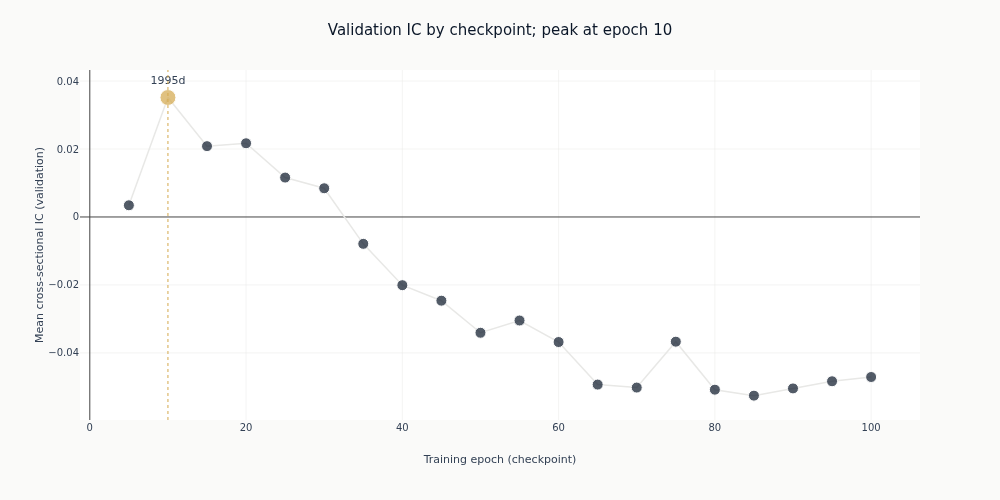

In [11]:
_epochs = checkpoints["checkpoint_value"].cast(pl.Int64).to_list()
_ics = checkpoints["ic_mean_daily"].to_list()
_days = checkpoints["ic_n_days"].to_list()
_colors = [
    COLORS["amber"]
    if epoch == PEAK_EPOCH
    else (COLORS["copper"] if epoch in partial_epochs else COLORS["blue"])
    for epoch in _epochs
]
fig_lc = go.Figure(
    go.Scatter(
        x=_epochs,
        y=_ics,
        mode="lines+markers+text",
        line=dict(color=COLORS["silver_muted"], width=1.5),
        marker=dict(
            color=_colors,
            size=[16 if epoch == PEAK_EPOCH else 11 for epoch in _epochs],
            line=dict(color="white", width=1),
        ),
        text=[
            f"{days:.0f}d" if epoch == PEAK_EPOCH or days < FULL_DAYS else ""
            for epoch, days in zip(_epochs, _days, strict=True)
        ],
        textposition="top center",
        showlegend=False,
    )
)
fig_lc.add_vline(x=PEAK_EPOCH, line=dict(color=COLORS["amber"], width=1, dash="dot"))
fig_lc.update_layout(
    title=(
        f"Validation IC by checkpoint; peak at epoch {PEAK_EPOCH}"
        + (f", partial epochs {partial_epochs} excluded" if partial_epochs else "")
    ),
    height=500,
    width=1000,
    margin=dict(t=70),
    title_font=dict(size=15),
)
fig_lc.update_xaxes(title_text="Training epoch (checkpoint)")
fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
fig_lc.show()

## 7. Against the flat-feature baselines

The peak checkpoint against the linear and gradient-boosting leaders. This is the comparison the
notebook exists to make: whether reading the history as a sequence adds anything over handing
the same history to a model as columns.

Each family's stored IC is computed over its own sample, and those samples are not the same:
sequence eligibility drops the warm-up rows a flat model keeps, so a shared date can carry a
different cross-section in each. Matching date counts would not settle it. The three prediction
sets are therefore intersected on their exact `(symbol, timestamp)` keys and the daily rank IC
is recomputed on the rows all three share - a smaller sample than any family's own, and the
only one on which they are a single comparison.

Common sample: 187,647 rows on 1,995 dates
  GBM (Ch12): IC=+0.0545 on the shared rows
  Ridge (Ch11): IC=+0.0432 on the shared rows
  TSMixer (tsmixer): IC=+0.0352 on the shared rows


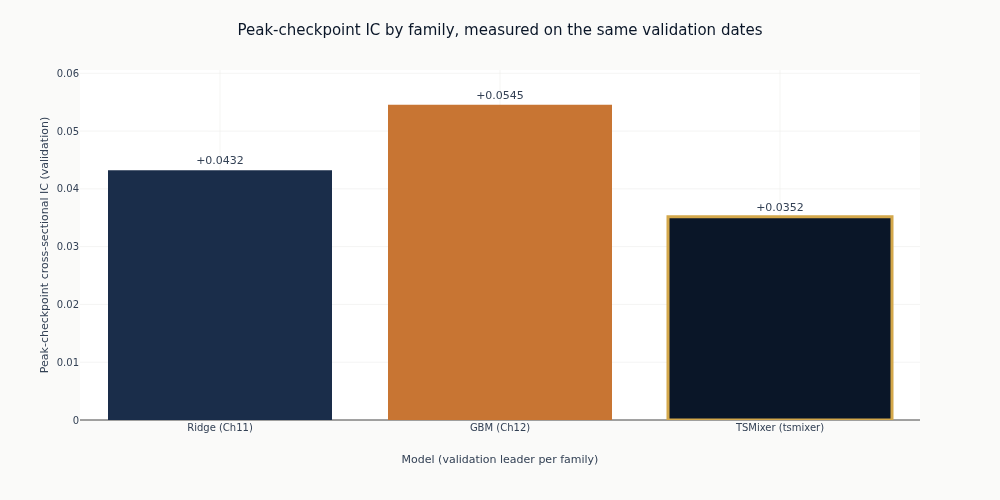

In [12]:
_missing = [name for name, phash in baseline_hashes.items() if not phash]
if _missing:
    raise RuntimeError(
        f"no prediction_hash registered for {_missing}, so their rows cannot be intersected "
        "with this notebook's; re-run the stage that published them"
    )

_frames = {
    name: load_predictions(CASE_STUDY_ID, prediction_hash=phash)
    for name, phash in baseline_hashes.items()
}
_frames[f"TSMixer ({CONFIG_NAME})"] = load_predictions(CASE_STUDY_ID, prediction_hash=PEAK_PHASH)
_empty = [name for name, frame in _frames.items() if frame.is_empty()]
if _empty:
    raise RuntimeError(f"no prediction rows on disk for {_empty}; the comparison cannot be made")

COMMON_IC, COMMON_DAYS, COMMON_ROWS = common_sample_daily_ic(_frames)
if not COMMON_IC:
    raise RuntimeError(
        "the three prediction sets share no (symbol, timestamp) rows, so there is no sample "
        "on which they can be compared"
    )
print(f"Common sample: {COMMON_ROWS:,} rows on {COMMON_DAYS:,} dates")
for _name, _ic in COMMON_IC.items():
    print(f"  {_name}: IC={_ic:+.4f} on the shared rows")

_labels = ["Ridge (Ch11)", "GBM (Ch12)", f"TSMixer ({CONFIG_NAME})"]
_vals = [COMMON_IC[name] for name in _labels]
fig_cmp = go.Figure(
    go.Bar(
        x=_labels,
        y=_vals,
        marker=dict(
            color=[COLORS["slate"], COLORS["copper"], COLORS["blue"]],
            line=dict(color=COLORS["amber"], width=[0, 0, 3]),
        ),
        text=[f"{value:+.4f}" for value in _vals],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
fig_cmp.update_layout(
    title="Peak-checkpoint IC by family, measured on the same validation dates",
    height=500,
    width=1000,
    margin=dict(t=70),
    title_font=dict(size=15),
)
fig_cmp.update_xaxes(title_text="Model (validation leader per family)")
fig_cmp.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_cmp.show()

## 8. Is the average stable across time?

The reported IC is an average over folds, and an average can be positive while most of its terms
are not. The per-fold breakdown is what separates a model with a weak but consistent edge from
one whose mean is carried by a single fold.

In [13]:
folds = (
    Result.open(study, PEAK_PHASH, include_preview=EXECUTION_TIER == "preview")
    .folds()
    .select("fold_id", "ic", "n_entities")
    .sort("fold_id")
)
print(f"Per-fold validation IC ({CONFIG_NAME} @ epoch {PEAK_EPOCH}):")
print(folds)
NEGATIVE_FOLDS = int(folds.filter(pl.col("ic") < 0).height)
print(f"\n  Folds with negative IC: {NEGATIVE_FOLDS} of {folds.height}")
print(f"  Peak-IC prediction_hash: {PEAK_PHASH}")

Per-fold validation IC (tsmixer @ epoch 10):
shape: (8, 3)
┌─────────┬───────────┬────────────┐
│ fold_id ┆ ic        ┆ n_entities │
│ ---     ┆ ---       ┆ ---        │
│ i64     ┆ f64       ┆ f64        │
╞═════════╪═══════════╪════════════╡
│ 0       ┆ -0.009287 ┆ 90.0       │
│ 1       ┆ -0.125377 ┆ 95.0       │
│ 2       ┆ 0.042411  ┆ 96.0       │
│ 3       ┆ 0.07674   ┆ 97.0       │
│ 4       ┆ 0.129033  ┆ 97.0       │
│ 5       ┆ 0.040575  ┆ 96.0       │
│ 6       ┆ 0.031986  ┆ 97.0       │
│ 7       ┆ 0.100668  ┆ 96.0       │
└─────────┴───────────┴────────────┘

  Folds with negative IC: 2 of 8
  Peak-IC prediction_hash: f3c22f02bdc3


## 9. What to notice

In [14]:
_coverage_text = (
    f"All {checkpoints.height} checkpoints cover {FULL_DAYS:.0f} validation dates."
    if not partial_epochs
    else f"Checkpoints at epochs {partial_epochs} were not published, on partial coverage."
)
display(
    Markdown(
        f"""
- **The globally shared model is measured against the flat-feature families on rows all three
  actually share** - {COMMON_ROWS:,} of them across {COMMON_DAYS:,} dates, intersected on
  `(symbol, timestamp)` and recomputed rather than assumed comparable. On that common sample the
  peak checkpoint scores **{COMMON_IC[f"TSMixer ({CONFIG_NAME})"]:+.3f}**, against Ridge
  **{COMMON_IC["Ridge (Ch11)"]:+.3f}** and GBM **{COMMON_IC["GBM (Ch12)"]:+.3f}**. Its own
  full-sample IC is **{PEAK_IC:+.3f}** at epoch **{PEAK_EPOCH}**.
- **Coverage is comparable across the checkpoint choice.** {_coverage_text} The guard stays
  necessary either way: a collapsed checkpoint scores on fewer dates and can look better for it.
- **The average is not the whole story.** The peak checkpoint is negative in
  **{NEGATIVE_FOLDS} of {folds.height}** validation folds. The holdout is not read here; it is
  evaluated once, after the development-stage selection is fixed.

**Next**: [`11_latent_factors`](11_latent_factors.ipynb) tests whether explicit factor
  structure organizes the cross-section more effectively.
**Book**: Chapter 13, Section 13.8 (Case Study Results).
"""
    )
)


- **The globally shared model is measured against the flat-feature families on rows all three
  actually share** - 187,647 of them across 1,995 dates, intersected on
  `(symbol, timestamp)` and recomputed rather than assumed comparable. On that common sample the
  peak checkpoint scores **+0.035**, against Ridge
  **+0.043** and GBM **+0.055**. Its own
  full-sample IC is **+0.035** at epoch **10**.
- **Coverage is comparable across the checkpoint choice.** All 20 checkpoints cover 1995 validation dates. The guard stays
  necessary either way: a collapsed checkpoint scores on fewer dates and can look better for it.
- **The average is not the whole story.** The peak checkpoint is negative in
  **2 of 8** validation folds. The holdout is not read here; it is
  evaluated once, after the development-stage selection is fixed.

**Next**: [`11_latent_factors`](11_latent_factors.ipynb) tests whether explicit factor
  structure organizes the cross-section more effectively.
**Book**: Chapter 13, Section 13.8 (Case Study Results).
